In [36]:
import pandas as pd
import numpy as np

In [37]:
df = pd.read_csv('titanic.csv')

In [38]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [39]:
df.isnull().sum()

Cabin       687
Ticket        0
number        0
Survived      0
dtype: int64

In [40]:
df.shape

(891, 4)

In [41]:

df['number'].unique()

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

Text(0.5, 1.0, 'Passengers travelling with')

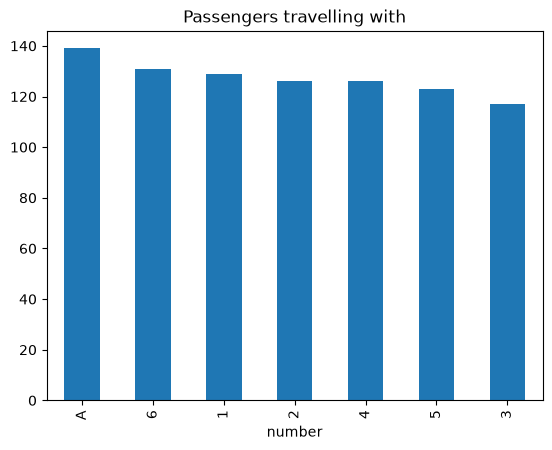

In [42]:
fig = df['number'].value_counts().plot.bar()
fig.set_title('Passengers travelling with')

##  1. Handling col with some cells have numerical value and some has categorical value

In [43]:
df['number_numerical'] = pd.to_numeric(
                            df["number"],errors='coerce',
                            downcast='integer')

In [44]:
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'],np.nan)

In [45]:
df

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A
...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN
887,B42,112053,3,1,3.0,NaN
888,NaN,W./C. 6607,1,0,1.0,NaN
889,C148,111369,2,1,2.0,NaN


##  2. Handling col with once cell have mixed value numerical + categorical both 

In [46]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [47]:
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [48]:
df['cabin_num'] = df['Cabin'].str.extract('(\d+)')
df['cabin_cat'] = df['Cabin'].str[0] # captures the first letter# captures numerical part

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Tarun Gupta\AppData\Local\Temp\ipykernel_23492\216751989.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num'] = df['Cabin'].str.extract('(\d+)')


In [49]:
df

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN
...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN,NaN,NaN
887,B42,112053,3,1,3.0,NaN,42,B
888,NaN,W./C. 6607,1,0,1.0,NaN,NaN,NaN
889,C148,111369,2,1,2.0,NaN,148,C


<Axes: xlabel='cabin_cat'>

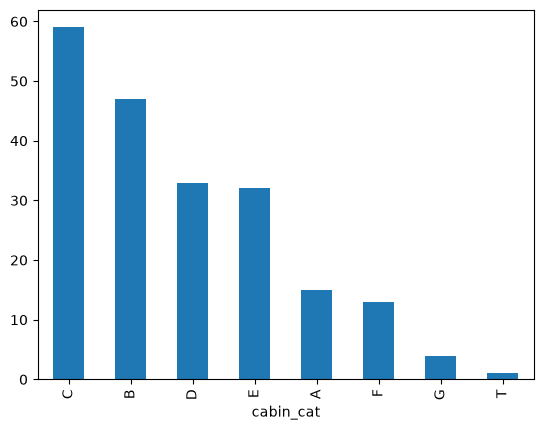

In [50]:
df['cabin_cat'].value_counts().plot(kind='bar')

In [51]:

# extract the last bit of ticket as number
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])

In [56]:
df['ticket_num'] = pd.to_numeric(df['ticket_num'],
                                   errors='coerce',
                                   downcast='integer')

In [57]:
df

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0
3,C123,113803,3,1,3.0,NaN,123,C,113803.0
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0
...,...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN,NaN,NaN,211536.0
887,B42,112053,3,1,3.0,NaN,42,B,112053.0
888,NaN,W./C. 6607,1,0,1.0,NaN,NaN,NaN,6607.0
889,C148,111369,2,1,2.0,NaN,148,C,111369.0


In [58]:
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])

In [59]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,113803
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,373450


In [60]:
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                              df['ticket_cat'])

In [61]:
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN


In [62]:
df.sample(5)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
886,NaN,211536,3,0,3.0,NaN,NaN,NaN,211536.0,NaN
735,NaN,54636,6,0,6.0,NaN,NaN,NaN,54636.0,NaN
395,NaN,350052,3,0,3.0,NaN,NaN,NaN,350052.0,NaN
596,NaN,248727,4,1,4.0,NaN,NaN,NaN,248727.0,NaN
620,NaN,2659,A,0,NaN,A,NaN,NaN,2659.0,NaN


In [65]:
df.drop(columns=['Cabin', 'number'], inplace=)

KeyError: "['Cabin', 'number'] not found in axis"

In [66]:
df

,Ticket,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,A/5 21171,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,PC 17599,1,3.0,NaN,85,C,17599.0,PC
2,STON/O2. 3101282,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,113803,1,3.0,NaN,123,C,113803.0,NaN
4,373450,0,NaN,A,NaN,NaN,373450.0,NaN
...,...,...,...,...,...,...,...,...
886,211536,0,3.0,NaN,NaN,NaN,211536.0,NaN
887,112053,1,3.0,NaN,42,B,112053.0,NaN
888,W./C. 6607,0,1.0,NaN,NaN,NaN,6607.0,W./C.
889,111369,1,2.0,NaN,148,C,111369.0,NaN
